<a href="https://colab.research.google.com/github/m-av-i/Fundamentos/blob/main/Coleta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print ("hello rafa")

hello rafa


##Configurações iniciais

In [ ]:
import httpx
from bs4 import BeautifulSoup
import time

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"
}

paginas = [
    "https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa?b_start:int=0",
    "https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa?b_start:int=30"
]

def acessar_pagina(link):
    try:
        response = httpx.get(link, headers=headers, timeout=20.0, follow_redirects=True)
        bs = BeautifulSoup(response.text, "html.parser")


        titulos = bs.select("#content-core .titulo")

        if not titulos:
            print(f"Nenhuma notícia encontrada em {link}. O layout pode ter mudado novamente.")
            return

        for h2_titulo in titulos:
            container = h2_titulo.find_parent("li")
            if not container:
                container = h2_titulo.find_parent("div") # Fallback

            titulo_txt = h2_titulo.text.strip()
            link_tag = h2_titulo.find("a")
            link_noticia = link_tag["href"] if link_tag else None

            if not link_noticia: continue


            span_data = container.find("span", class_="date")
            raw_date = span_data.text.strip() if span_data else "Data não encontrada"

            parts = raw_date.split()
            data = parts[0] if len(parts) > 0 else "-"
            horario = parts[1] if len(parts) > 1 else "-"

            numero_nota = titulo_txt.split("nº")[-1].strip() if "nº" in titulo_txt else "N/A"

            paragrafos = "Não extraído"
            try:

                #sleep pra não ser kickado rs
                time.sleep(0.5)
                res_detalhe = httpx.get(link_noticia, headers=headers, timeout=10.0, follow_redirects=True)
                bs_detalhe = BeautifulSoup(res_detalhe.text, "html.parser")


                corpo = bs_detalhe.find("div", id="parent-fieldname-text")
                if not corpo:
                    corpo = bs_detalhe.find("div", property="rnews:articleBody")

                if corpo:
                    paragrafos = "\n".join([p.text.strip() for p in corpo.find_all("p") if p.text.strip()])
                    paragrafos = paragrafos[:200] + "..." # Truncando pro print não ficar gigante
            except Exception:
                pass

            print(f"Nota: {numero_nota}")
            print(f"Data: {data} | Hora: {horario}")
            print(f"Título: {titulo_txt}")
            print(f"Link: {link_noticia}")
            print(f"Texto: {paragrafos}")
            print("-" * 50)

    except Exception as e:
        print(f"Erro ao processar página {link}: {e}")


for p in paginas:
    print(f">>> Lendo: {p}")
    acessar_pagina(p)

>>> Lendo: https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa?b_start:int=0
Nota: N/A
Data: Data | Hora: não
Título: Escalada de hostilidades no Oriente Médio
Link: https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/escalada-de-hostilidades-no-oriente-medio
Texto: O Governo brasileiro manifesta profunda preocupação com a escalada de hostilidades na região do Golfo, que representa uma grave ameaça à paz e à segurança internacionais, com potenciais impactos human...
--------------------------------------------------
Nota: N/A
Data: Data | Hora: não
Título: Acidente aéreo na Bolívia
Link: https://www.gov.br/mre/pt-br/canais_atendimento/imprensa/notas-a-imprensa/acidente-aereo-na-bolivia
Texto: O Governo brasileiro expressa solidariedade ao Governo e ao povo bolivianos pelo acidente envolvendo avião da Força Aérea da Bolívia, em 27/2. Expressa, ainda, condolências às famílias das vítimas e d...
--------------------------------------------------

In [ ]:
Acesso ao Google Drive
Uma forma prática de acessar sua base de dados para análise com o Google Colab é fazendo upload dos arquivos no Google Drive.
O comando a seguir dá ao Colab acesso aos arquivos do usuário no Google Drive.

##Configurações iniciais

In [ ]:
import json
import numpy as np
import pandas as pd
import plotly.express as px

###Acesso ao Google Drive
#####Uma forma prática de acessar sua base de dados para análise com o Google Colab é fazendo upload dos arquivos no Google Drive.
#####O comando a seguir dá ao Colab acesso aos arquivos do usuário no Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


###Acesso à base de dados

#####Após permitir o acesso do Colab ao Drive, é necessário especificar o caminho do arquivo a qual se deseja analisar.   
#####Caso a pasta ou o arquivo desejado não estejam em seu Google Drive, é necessário criar um atalho.

#####Link da pasta que está sendo utulizada como exemplo: https://drive.google.com/drive/folders/1xPoFDSQjsU7siKnI82SGKFQ95MFZaQVb   
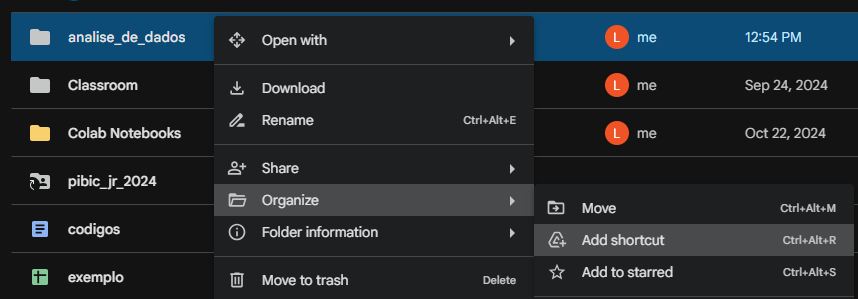

#####Após criar o atalho, é necessário identificar o caminho do arquivo.
#####Para localizar o arquivo com o Google Colab, serão criadas duas variáveis: 'caminho_padrao', que irá receber '/content/gdrive/MyDrive' (o caminho universal para arquivos e pastas localizados no seu Drive) e 'caminho_especifico', que receberá as pastas onde o arquivo está inserido. Caso o arquivo se encontre diretamente em 'Meu Drive', o caminho específico é desnecessário.

#####As informações são separadas em duas variáveis para facilitar a manutenção de informações, caso o arquivo seja movido dentro do Drive.

#####Depois, elas serão juntas em uma terceira variável: 'caminho_completo', que deve concatenar as duas variáveis anteriores, respectivamente.

In [ ]:
caminho_padrao = '/content/gdrive/MyDrive'
caminho_especifico = '/analise_de_dados'
caminho_completo = caminho_padrao + caminho_especifico

##Introdução ao Pandas


###DataFrames

#####Um DataFrame é uma estrutura de dados bidimensional e tabular, com rótulos para linhas e colunas. Ele pode armazenar diversos tipos de dados, como números inteiros e flutuantes, listas, caracteres etc.
#####Exemplo de DataFrame:

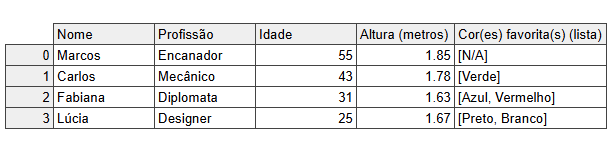


####Criando um DataFrame


#####Uma das maneiras possíveis de se criar um DataFrame em Python é criando um dicionário de listas, onde as chaves dos dicionários são os nomes das colunas da tabela.
#####Para saber mais sobre dicionários e listas em Python, acesse: https://www.devmedia.com.br/colecoes-no-python-listas-tuplas-e-dicionarios/40678

In [ ]:
#definição do dicionário:
dados = {
    'Nome': ['Marcos', 'Carlos', 'Fabiana', 'Lúcia'],
    'Profissão': ['Encanador', 'Mecânico', 'Diplomata', 'Designer'],
    'Idade': [55, 43, 31, 25],
    'Altura': [1.85, 1.78, 1.63, 1.67],
    'Cor Favorita': [['N/A'], ['Verde'], ['Azul','Vermelho'], ['Preto', 'Branco']]
}

df = pd.DataFrame(dados) #a função '.DataFrame(parametro)' transforma o parametro em DataFrame
print(df)


      Nome  Profissão  Idade  Altura      Cor Favorita
0   Marcos  Encanador     55    1.85             [N/A]
1   Carlos   Mecânico     43    1.78           [Verde]
2  Fabiana  Diplomata     31    1.63  [Azul, Vermelho]
3    Lúcia   Designer     25    1.67   [Preto, Branco]


####Separando partes de um DataFrame
#####Dependendo da análise que se deseja fazer, pode ser mais interessante separar apenas algumas colunas de um DataFrame para trabalhar melhor coc as informações.

In [ ]:
#selecionando apenas uma coluna
df_nomes = df['Nome']
print(df_nomes)

0     Marcos
1     Carlos
2    Fabiana
3      Lúcia
Name: Nome, dtype: object


In [ ]:
#selecionando mais de uma coluna
df_nome_idade_profissao = df[['Nome', 'Idade', 'Profissão']]
print(df_nome_idade_profissao)

      Nome  Idade  Profissão
0   Marcos     55  Encanador
1   Carlos     43   Mecânico
2  Fabiana     31  Diplomata
3    Lúcia     25   Designer


####Criando novas colunas a partir de colunas existentes

In [ ]:
#selecionar uma coluna não existente no DataFrame cria uma nova coluna!
df['Ano de Nascimento'] = 2025 - df['Idade']
print(df)

      Nome  Profissão  Idade  Altura      Cor Favorita  Ano de Nascimento
0   Marcos  Encanador     55    1.85             [N/A]               1970
1   Carlos   Mecânico     43    1.78           [Verde]               1982
2  Fabiana  Diplomata     31    1.63  [Azul, Vermelho]               1994
3    Lúcia   Designer     25    1.67   [Preto, Branco]               2000


###Series

####Uma Series é uma estrutura unidimensional de dados rotulada. Cada coluna de um DataFrame é uma Series.
####Exemplo de Series:
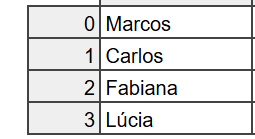

####Criando uma Series
#####Uma Series pode ser criada a partir de uma lista ou de uma coluna de um DataFrame preexistente.

In [ ]:
#criando uma Series a partir de uma lista
nomes = ['Marcos', 'Carlos', 'Fabiana', 'Lúcia']
nomes_series = pd.Series(nomes, name='Nomes') #a função '.Series(parametro, name='rótulo')' transforma o parametro em Series
print("Series de Nomes:\n")
print(nomes_series)

Series de Nomes:

0     Marcos
1     Carlos
2    Fabiana
3      Lúcia
Name: Nomes, dtype: object


In [ ]:
#criando series a partir de DataFrame existente
nomes = df['Nome']
print("Series de Nomes Extraídos do DataFrame:\n")
print(nomes)

Series de Nomes Extraídos do DataFrame:

0     Marcos
1     Carlos
2    Fabiana
3      Lúcia
Name: Nome, dtype: object


In [ ]:
#dá pra definir índices personalizados

idades_series = pd.Series([55, 43, 31, 25], index=nomes)
#o parâmetro 'index' determina os novos índices dos dados da Series

print("Series de Idades com Índices Personalizados:\n")
print(idades_series)

Series de Idades com Índices Personalizados:

Nome
Marcos     55
Carlos     43
Fabiana    31
Lúcia      25
dtype: int64


###Conversão de arquivos












#####Além de criar seus próprios DataFrames do zero, é possível importar bases de dados já existentes.
#####O comando ```pd.read_``` consegue transformar os seguintes tipos de arquivo em DataFrame:
* CSV:  ``` pd.read_csv() ```
* JSON: ``` pd.read_json() ```
* HTML: ``` pd.read_html()```
* Excel: ``` pd.read_excel() ```
* Parquet: ``` pd.read_parquet() ```
* ORC: ``` pd.read_orc() ```
* SAS: ``` pd.read_sas() ```
* SPSS: ``` pd.read_spss()```
* Stata: ```pd.read_stata()```
* Clipboard: ```pd.read_clipboard()```
* FWF:``` pd.read_fwf()```
* SQL:``` pd.read_sql(), pd.read_sql_table(), pd.read_sql_query()```
* Google BigQuery: ```pd.read_gbq()```
* HDF5: ```pd.read_hdf()```

####Criando um DataFrame a partir de arquivo .csv

In [ ]:
df = pd.read_csv(f'{caminho_completo}/exemplo_em_csv.csv')
print(df)

      Nome  Profissão  Idade  Altura (metros) Cor(es) favorita(s) (lista)
0   Marcos  Encanador     55             1.85                       [N/A]
1   Carlos   Mecânico     43             1.78                     [Verde]
2  Fabiana  Diplomata     31             1.63            [Azul, Vermelho]
3    Lúcia   Designer     25             1.67             [Preto, Branco]


####Criando um arquivo a partir de um DataFrame
#####Além de transformar arquivos em DataFrame, é possível fazer o inverso com o comando ```.to_```

In [ ]:
dados = {
    'Nome': ['Marcos', 'Carlos', 'Fabiana', 'Lúcia'],
    'Profissão': ['Encanador', 'Mecânico', 'Diplomata', 'Designer'],
    'Idade': [55, 43, 31, 25],
    'Altura': [1.85, 1.78, 1.63, 1.67],
    'Cor Favorita': [['N/A'], ['Verde'], ['Azul','Vermelho'], ['Preto', 'Branco']]
}

df = pd.DataFrame(dados)

df.to_json(f'{caminho_completo}/exemplo_to_json.json') #salva o DataFrame em um arquivo JSON


###Comparando e juntando DataFrames

####Função `pd.compare()`

#####A função `pd.compare()` compara dois DataFrames e resume suas diferenças. Somente as diferenças são exibidas, enquanto os valores iguais são mostrados como 'NaN'.
#####Só é possível comparar DataFrames que possuam colunas idênticas, em quantidade e nome.

In [ ]:
dados = {
    'Nome': ['Marcos', 'Carlos', 'Fabiana', 'Lúcia'],
    'Profissão': ['Encanador', 'Mecânico', 'Diplomata', 'Designer'],
    'Idade': [55, 43, 31, 25],
    'Altura': [1.85, 1.78, 1.63, 1.67],
    'Cor Favorita': [['N/A'], ['Verde'], ['Azul','Vermelho'], ['Preto', 'Branco']]
}

df = pd.DataFrame(dados)


dados2 = {
    'Nome': ['Marcos', 'Henrique', 'Fabiana', 'Lúcia'],
    'Profissão': ['Pedreiro', 'Mecânico', 'Diplomata', 'Designer'],
    'Idade': [55, 43, 31, 21],
    'Altura': [1.85, 1.78, 1.63, 1.67],
    'Cor Favorita': [['N/A'], ['Verde'], ['Azul','Roxo'], ['Preto', 'Branco']]
}
df2 = pd.DataFrame(dados2)

df.compare(df2)

Nome            Profissão           Idade            Cor Favorita  \
     self     other       self     other  self other              self   
0     NaN       NaN  Encanador  Pedreiro   NaN   NaN               NaN   
1  Carlos  Henrique        NaN       NaN   NaN   NaN               NaN   
2     NaN       NaN        NaN       NaN   NaN   NaN  [Azul, Vermelho]   
3     NaN       NaN        NaN       NaN  25.0  21.0               NaN   

                 
          other  
0           NaN  
1           NaN  
2  [Azul, Roxo]  
3           NaN

In [ ]:
df.compare(df2, keep_equal=True) #o parâmetro 'keep_equal=True' mantém os valores iguais na exibição da comparação

Nome            Profissão            Idade            Cor Favorita  \
      self     other       self      other  self other              self   
0   Marcos    Marcos  Encanador   Pedreiro    55    55             [N/A]   
1   Carlos  Henrique   Mecânico   Mecânico    43    43           [Verde]   
2  Fabiana   Fabiana  Diplomata  Diplomata    31    31  [Azul, Vermelho]   
3    Lúcia     Lúcia   Designer   Designer    25    21   [Preto, Branco]   

                    
             other  
0            [N/A]  
1          [Verde]  
2     [Azul, Roxo]  
3  [Preto, Branco]

####Função `pd.concat()`

#####A função `pd.concat()` junta DataFrames ou Series, vertical ou horiontalmente. É semelhante a empilhar DataFrames, ou os colocá-los lado a lado.

In [ ]:
dados = {
    'Nome': ['Marcos', 'Carlos', 'Fabiana', 'Lúcia'],
    'Profissão': ['Encanador', 'Mecânico', 'Diplomata', 'Designer'],
    'Idade': [55, 43, 31, 25],
    'Altura': [1.85, 1.78, 1.63, 1.67],
    'Cor Favorita': [['N/A'], ['Verde'], ['Azul','Vermelho'], ['Preto', 'Branco']]
}
df = pd.DataFrame(dados)

dados_novos = {
    'Nome': ['Júlia', 'Pedro'],
    'Profissão': ['Confeiteira', 'Professor'],
    'Idade': [22, 32],
    'Altura': [1.75, 1.68],
    'Cor Favorita': [['Rosa'], ['Verde']],
    'Salário': [2000, 4000] #os DataFrames não precisam ter as mesmas colunas para usar o '.concat()'
}

df_dados_novos = pd.DataFrame(dados_novos, index=[4, 5])

pd.concat([df, df_dados_novos]) #junta os DataFrames verticalmente


,Nome,Profissão,Idade,Altura,Cor Favorita,Salário
0,Marcos,Encanador,55,1.85,[N/A],NaN
1,Carlos,Mecânico,43,1.78,[Verde],NaN
2,Fabiana,Diplomata,31,1.63,"[Azul, Vermelho]",NaN
3,Lúcia,Designer,25,1.67,"[Preto, Branco]",NaN
4,Júlia,Confeiteira,22,1.75,[Rosa],2000.0
5,Pedro,Professor,32,1.68,[Verde],4000.0


In [ ]:
colunas_novas = {
    'Salário': [3500, 5000, 15000, 2500],
    'Sexo': ['M', 'M', 'F', 'F']
}
df_colunas_novas = pd.DataFrame(colunas_novas)

series_cidades = pd.Series(["São Paulo", "Franca", "Cairo", "Belo Horizonte"], name="Cidade")
 #o parâmetro "name" define o rótulo da Series quando ela for para o DataFrame

pd.concat([df, df_colunas_novas, series_cidades], axis=1) #o parâmetro 'axis=1' junta os DataFrames horizontalmente

,Nome,Profissão,Idade,Altura,Cor Favorita,Salário,Sexo,Cidade
0,Marcos,Encanador,55,1.85,[N/A],3500,M,São Paulo
1,Carlos,Mecânico,43,1.78,[Verde],5000,M,Franca
2,Fabiana,Diplomata,31,1.63,"[Azul, Vermelho]",15000,F,Cairo
3,Lúcia,Designer,25,1.67,"[Preto, Branco]",2500,F,Belo Horizonte


####Função `pd.merge()`

#####A função `pd.merge()` combina dois DataFrames com base em chaves em comum entre eles.
#####A sintaxe do `pd.merge()` é a seguinte:
#####```pd.merge(left, right, how='inner', on=None, left_on=None, right_on=None)```
#####Onde:

*   `left` é o primeiro DataFrame
*   `right` é o segundo DataFrame  
*   `on` especifica a(s) coluna(s) que será(ão) a chave da união. Exemplo `on=['Nome', 'Idade']`. Os dados se juntam quando as colunas-chave dos DataFrame forem correspondentes.
*   `left_on` é a coluna que será a chave do primeiro DataFrame, caso as colunas chave tenham nomes diferentes nos dois DataFrames
*   `right_on` é a coluna que será a chave do segundo DataFrame, caso as colunas chave tenham nomes diferentes nos dois DataFrames
*   `how` é o método de união, sendo eles:
    *   `inner` (padrão): retorna a intersecção entre os DataFrames (chaves que têm correspondência nos dois DataFrames).  
    *   `outer`: retorna a união entre os DataFrames, todas as linhas dos dois. Dados que não têm correspondência em um dos lados são retornados como `NaN`.
    *   `left`: retorna todas as linhas do primeiro DataFrame e suas correspondências com o segundo. Caso não haja correspondência em alguma linha, ela é retonada como `Nan`.
    *   `right`: retorna todas as linhas do segundo DataFrame e suas correspondências com o primeiro. Caso não haja correspondência em alguma linha, ela é retonada como `Nan`.


In [ ]:
#exemplo 1: chaves dos dois DFs têm o mesmo nome

dados = {
    'Nome': ['Marcos', 'Carlos', 'Fabiana', 'Lúcia'],
    'Profissão': ['Encanador', 'Mecânico', 'Diplomata', 'Designer'],
    'Idade': [55, 43, 31, 25],
    'Altura': [1.85, 1.78, 1.63, 1.67],
    'Cor Favorita': [['N/A'], ['Verde'], ['Azul','Vermelho'], ['Preto', 'Branco']]
}
df = pd.DataFrame(dados)

df_hobbies = {
    'Nome': ['Marcos', 'Fabiana', 'Jurandir'],
    'Hobby': ['Jardinagem', 'Leitura', 'Natação']
}
df_hobbies = pd.DataFrame(df_hobbies)


df_merged= pd.merge(df, df_hobbies, on='Nome', how='inner')
#df_merged= pd.merge(df, df_hobbies, on='Nome', how='outer')
#df_merged= pd.merge(df, df_hobbies, on='Nome', how='left')
#df_merged= pd.merge(df, df_hobbies, on='Nome', how='right')

print(df_merged)

      Nome  Profissão  Idade  Altura      Cor Favorita       Hobby
0   Marcos  Encanador     55    1.85             [N/A]  Jardinagem
1  Fabiana  Diplomata     31    1.63  [Azul, Vermelho]     Leitura


In [ ]:
#exemplo 2: chaves dos dois DFs têm nomes diferentes

dados = {
    'Nome': ['Marcos', 'Carlos', 'Fabiana', 'Lúcia'],
    'Profissão': ['Encanador', 'Mecânico', 'Diplomata', 'Designer'],
    'Idade': [55, 43, 31, 25],
    'Altura': [1.85, 1.78, 1.63, 1.67],
    'Cor Favorita': [['N/A'], ['Verde'], ['Azul','Vermelho'], ['Preto', 'Branco']]
}
df = pd.DataFrame(dados)

df_hobbies = {
    'Pessoa': ['Marcos', 'Fabiana', 'Jurandir'],
    'Hobby': ['Jardinagem', 'Leitura', 'Natação']
}
df_hobbies = pd.DataFrame(df_hobbies)


df_merged= pd.merge(df, df_hobbies, left_on='Nome', right_on='Pessoa', how='inner')
print(df_merged)

      Nome  Profissão  Idade  Altura      Cor Favorita   Pessoa       Hobby
0   Marcos  Encanador     55    1.85             [N/A]   Marcos  Jardinagem
1  Fabiana  Diplomata     31    1.63  [Azul, Vermelho]  Fabiana     Leitura


In [ ]:
#exemplo 3: duas colunas como chave

dados = {
    'Nome': ['Marcos', 'Carlos', 'Fabiana', 'Lúcia', 'Lúcia'],
    'Profissão': ['Encanador', 'Mecânico', 'Diplomata', 'Designer', 'Marinheira'],
    'Idade': [55, 43, 31, 25, 42],
    'Altura': [1.85, 1.78, 1.63, 1.67, 1.76],
    'Cor Favorita': [['N/A'], ['Verde'], ['Azul','Vermelho'], ['Preto', 'Branco'], ['Azul']]
}
df = pd.DataFrame(dados)

df_hobbies = {
    'Nome': ['Marcos', 'Fabiana', 'Jurandir', 'Lúcia', 'Lúcia'],
    'Profissão': ['Encanador', 'Diplomata', 'Porteiro', 'Pintora', 'Marinheira'],
    'Hobby': ['Jardinagem', 'Leitura', 'Natação', 'Desenhar', 'Crochê']
}
df_hobbies = pd.DataFrame(df_hobbies)


df_merged= pd.merge(df, df_hobbies, on=['Nome', 'Profissão'], how='inner')
#o merge só é realizado quando as duas colunas são iguais nos dois DataFrames
print(df_merged)

      Nome   Profissão  Idade  Altura      Cor Favorita       Hobby
0   Marcos   Encanador     55    1.85             [N/A]  Jardinagem
1  Fabiana   Diplomata     31    1.63  [Azul, Vermelho]     Leitura
2    Lúcia  Marinheira     42    1.76            [Azul]      Crochê


####Função `df.join()`

#####A função `df.join()` junta dois DataFrames com base em seus índices (por padrão) ou em alguma coluna específica, comum aos dois DataFrames. É menos complexo que o `pd.merge()`, portante é utilizado em situações que precisam de uma junção mais simples.
#####Diferente do `pd.merge()`, o `df.join()` é um método dos DataFrames. Sua sintaxe básica é:
####`df.join(other, on=None, how='left')`
#####Onde:
*   `df` é o nome do DataFrame.
*   `other` é o DataFrame que se deseja juntar ao primeiro.
*   `on` especifica a colunabque será a chave da união. Se não for preenchido, a chave da união serão os índices das linhas.
*   `how` é o método de união, sendo eles:
    *   `inner` (padrão): retorna a intersecção entre os DataFrames (chaves que têm correspondência nos dois DataFrames).  
    *   `outer`: retorna a união entre os DataFrames, todas as linhas dos dois. Dados que não têm correspondência em um dos lados são retornados como `NaN`.
    *   `left`: retorna todas as linhas do primeiro DataFrame e suas correspondências com o segundo. Caso não haja correspondência em alguma linha, ela é retonada como `Nan`.
    *   `right`: retorna todas as linhas do segundo DataFrame e suas correspondências com o primeiro. Caso não haja correspondência em alguma linha, ela é retonada como `Nan`.

In [ ]:
#exemplo 2: utilizando o índice padrão

dados = {
    'Nome': ['Marcos', 'Carlos', 'Fabiana', 'Lúcia'],
    'Profissão': ['Encanador', 'Mecânico', 'Diplomata', 'Designer'],
    'Idade': [55, 43, 31, 25],
    'Altura': [1.85, 1.78, 1.63, 1.67],
    'Cor Favorita': [['N/A'], ['Verde'], ['Azul','Vermelho'], ['Preto', 'Branco']]
}
df = pd.DataFrame(dados)

df_hobbies = {
    'Hobby': ['Jardinagem','Culinária', 'Leitura', 'Crochê', 'Natação']
}
df_hobbies = pd.DataFrame(df_hobbies)


df.join(df_hobbies,  how='inner')

,Nome,Profissão,Idade,Altura,Cor Favorita,Hobby
0,Marcos,Encanador,55,1.85,[N/A],Jardinagem
1,Carlos,Mecânico,43,1.78,[Verde],Culinária
2,Fabiana,Diplomata,31,1.63,"[Azul, Vermelho]",Leitura
3,Lúcia,Designer,25,1.67,"[Preto, Branco]",Crochê


In [ ]:
#exemplo 2: mudando o índice

dados = {
    'Nome': ['Marcos', 'Carlos', 'Fabiana', 'Lúcia'],
    'Profissão': ['Encanador', 'Mecânico', 'Diplomata', 'Designer'],
    'Idade': [55, 43, 31, 25],
    'Altura': [1.85, 1.78, 1.63, 1.67],
    'Cor Favorita': [['N/A'], ['Verde'], ['Azul','Vermelho'], ['Preto', 'Branco']]
}
df = pd.DataFrame(dados)
df = df.set_index('Nome') #define a coluna 'Nome' como o índice do DataFrame

df_hobbies = {
    'Nome': ['Marcos', 'Fabiana', 'Jurandir'],
    'Hobby': ['Jardinagem', 'Leitura', 'Natação']
}
df_hobbies = pd.DataFrame(df_hobbies)
df_hobbies = df_hobbies.set_index('Nome') #define a coluna 'Nome' como o índice do DataFrame


df.join(df_hobbies,  how='inner')

,Profissão,Idade,Altura,Cor Favorita,Hobby
Nome,,,,,
Marcos,Encanador,55,1.85,[N/A],Jardinagem
Fabiana,Diplomata,31,1.63,"[Azul, Vermelho]",Leitura


###Estatísticas Básicas

In [ ]:
dados = {
    'Nome': ['Marcos', 'Carlos', 'Fabiana', 'Lúcia'],
    'Profissão': ['Encanador', 'Mecânico', 'Diplomata', 'Designer'],
    'Idade': [55, 43, 31, 25],
    'Altura': [1.85, 1.78, 1.63, 1.67],
    'Cor Favorita': [['N/A'], ['Verde'], ['Azul','Vermelho'], ['Verde']]
}
df = pd.DataFrame(dados)

#máximos e mínimos
max_idade = df['Idade'].max()
min_idade = df['Idade'].min()
print(f'A maior idade é: {max_idade}')
print(f'A menor idade é: {min_idade}')

#calculando a média de altura
media_altura = df['Altura'].mean()
print(f'A média de altura é: {media_altura}\n')

#calculando a mediana de altura
mediana_altura = df['Altura'].median()
print(f'A mediana de altura é: {mediana_altura}\n')

#moda das cores favoritas
moda_cores = df['Cor Favorita'].mode()
print(f'A moda das cores favoritas é: {moda_cores}\n')


A maior idade é: 55
A menor idade é: 25
A média de altura é: 1.7325

A mediana de altura é: 1.725

A moda das cores favoritas é: 0    [Verde]
Name: Cor Favorita, dtype: object



####`df.describe()`
#####A função `df.describe()` exibe um resumo estatístico do DataFrame

In [ ]:
dados = {
    'Nome': ['Marcos', 'Carlos', 'Fabiana', 'Lúcia'],
    'Profissão': ['Encanador', 'Mecânico', 'Diplomata', 'Designer'],
    'Idade': [55, 43, 31, 25],
    'Altura': [1.85, 1.78, 1.63, 1.67],
    'Cor Favorita': [['N/A'], ['Verde'], ['Azul','Vermelho'], ['Verde']],
    'Sexo': ['M', 'M', 'F', 'F']
}
df = pd.DataFrame(dados)
df.describe()

,Idade,Altura
count,4.000000,4.000000
mean,38.500000,1.732500
std,13.304135,0.100789
min,25.000000,1.630000
25%,29.500000,1.660000
50%,37.000000,1.725000
75%,46.000000,1.797500
max,55.000000,1.850000


###Agrupando dados com `df.groupby()`

#####A função `df.groupby()` descrve uma ou mais das etapas a seguir:


*   Split (dividir), que separa pequenos grupos de um DataFrame com base em chaves(colunas).
*   Apply (aplicar), que aplica uma função a cada grupo de dados. Existem três tipos de função que podem ser aplicadas:
      *   Funções de Agregação: calcula estatísticas de cada grupo.
      *   Funções de Transformação: modifica os valores e retorna um grupo com indíces iguais.
      *   Funções de Filtragem: descarta alguns valores do grupo.
*   Combine (combinar), que combina os resultados em uma estrutura de dados.

#####A sintaxe básica do `df.groupby()` é:
```
df.groupby(by=None, dropna=True)
```
#####Sendo:

*   `df` o DataFrame a qual se quer aplicar a função.
*   `by` a(s) chave(s) da separação de grupos (uma ou mais colunas do DataFrame).

In [ ]:
# calculando a quantidade de pessoas por sexo
pessoas_por_sexo = df.groupby('Sexo').size()
print(f"Pessoas por sexo {pessoas_por_sexo}\n")

# calculando a média de idade por sexo
idade_por_sexo = df.groupby('Sexo')['Idade'].mean()
print(f"Média de idade por sexo {idade_por_sexo}\n")

Pessoas por sexo Sexo
F    2
M    2
dtype: int64

Média de idade por sexo Sexo
F    28.0
M    49.0
Name: Idade, dtype: float64



In [ ]:
# agrupando e aplicando múltiplas funções de agregação
analise = df.groupby('Sexo').agg(
    total_pessoas=('Nome', 'count'),  # conta o número de nomes (pessoas)
    idade_media=('Idade', 'mean'),    # calcula a média da idade
    altura_media=('Altura', 'mean')   # calcula a média da altura
)
print(analise)


      total_pessoas  idade_media  altura_media
Sexo                                          
F                 2         28.0         1.650
M                 2         49.0         1.815


###Gráficos com a biblioteca ` Plotly Express`

####Sintaxe geral da geração de gráficos com `Plotly Express`:
`px.tipo_de_grafico(data_frame, x='nome_da_coluna', y='nome_da_coluna', ...)`

####Sendo:


*   `tipo_de_grafico`  função que corresponde ao gráfico desejado, sendo eles:
    *   `line`: gráfico de linha
    *   `bar`: gráfico de barras
    *   `pie`: gráfico de setores
    *   `histogram `: histograma
* `data_frame` é o DataFrame a partir de qual o gráfico será feito
*   `x='nome_da_coluna'` e` y='nome_da_coluna'` são as colunas correspondentes aos eixos x e y do gráfico (não é utilizado no gráfico de setores, sendo substituidos por `values = nome_da_coluna`)


In [ ]:
dados = {
    'Cidade': ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Porto Alegre', 'Curitiba', 'São Paulo', 'Rio de Janeiro'],
    'Vendas': [150, 120, 80, 70, 90, 160, 130],
    'Lucro': [20, 15, 10, 8, 12, 22, 16],
    'Ano': [2023, 2023, 2023, 2024, 2024, 2024, 2024],
    'Tipo Produto': ['Eletrônico', 'Roupa', 'Eletrônico', 'Alimento', 'Roupa', 'Eletrônico', 'Alimento']
}
df = pd.DataFrame(dados)

####Gráfico de barras

In [ ]:
df_produto = df.groupby('Tipo Produto')['Vendas'].sum().reset_index()
fig_bar = px.bar(df_produto, x='Tipo Produto', y='Vendas',
                 title='Vendas Totais por Tipo de Produto')
fig_bar.show()

####Gráfico de linha


In [ ]:
data_time_series = {
    'Ano': [2020, 2021, 2022, 2023, 2020, 2021, 2022, 2023],
    'Cidade': ['SP', 'SP', 'SP', 'SP', 'RJ', 'RJ', 'RJ', 'RJ'],
    'Vendas': [100, 120, 150, 180, 80, 95, 110, 130]
}
df_ts = pd.DataFrame(data_time_series)
fig_line2 = px.line(df_ts, x='Ano', y='Vendas', color='Cidade',
                    title='Vendas Anuais por Cidade')
fig_line2.show()

####Gráfico de seções (pizza)

In [ ]:
df_produto_pie = df.groupby('Tipo Produto')['Vendas'].sum().reset_index()
fig_pie = px.pie(df_produto_pie, values='Vendas', names='Tipo Produto',
                 title='Proporção de Vendas por Tipo de Produto')
fig_pie.show()

###Aplicando funções personalizadas no DataFrame/Series

#####A função ```.apply()``` permite aplicar funções personalizadas (funções que não são nativas do Pandas ou do Python) em um DataFrame inteiro ou em uma Series.
#####A sintaxe do ```.apply()``` é: ```df.apply(func, axis=0, args=())```
#####Onde:
* `func` é a função personalizada.
* `axis` é a orientação em que a função será aplicada, sendo `axis = 0 ` (padrão) coluna por coluna e `axis = 1`, linha por linha (apenas para DataFrames).
* `args` são os argumentos da função.

#####Podem ser aplicadas funções anônimas com `lambda` ou funções definidas com `def`. Além disso, o `.apply()` é muito utilizado para realizar cálculos entre colunas do DataFrame.
#####Alguns exemplos de utilizações comuns do `.apply()` abaixo:

In [ ]:
dados = {
    'Produto': ['Maçã', 'Banana', 'Cenoura', 'Detergente', 'Ovos'],
    'Preco_Unitario': [2.50, 4.00, 1.80, 7.20, 12.00],
    'Quantidade_Vendida': [10, 5, 20, 2, 3],
    'Categoria': ['Fruta', 'Fruta', 'Vegetal', 'Limpeza', 'Mercearia']
}
df = pd.DataFrame(dados)


#1. função anônima (lambda)
df['Classificacao_Vendas'] = df['Quantidade_Vendida'].apply(lambda vendas: 'Vendeu Pouco' if vendas < 10 else 'Vendeu Muito')


#2. função definida (def)
def comestivel(categoria):
    if categoria in ['Fruta', 'Vegetal']:
        return 'Sim'
    else:
        return 'Não'

df['Comestível'] = df['Categoria'].apply(comestivel)


#3. cálculo entre colunas (usando **axis=1**)
def calcular_total_venda(linha):
    return linha['Preco_Unitario'] * linha['Quantidade_Vendida']

df['Valor_Total_Venda'] = df.apply(calcular_total_venda, axis=1)

df.head()

,Produto,Preco_Unitario,Quantidade_Vendida,Categoria,Classificacao_Vendas,Comestível,Valor_Total_Venda
0,Maçã,2.5,10,Fruta,Vendeu Muito,Sim,25.0
1,Banana,4.0,5,Fruta,Vendeu Pouco,Sim,20.0
2,Cenoura,1.8,20,Vegetal,Vendeu Muito,Sim,36.0
3,Detergente,7.2,2,Limpeza,Vendeu Pouco,Não,14.4
4,Ovos,12.0,3,Mercearia,Vendeu Pouco,Não,36.0


##Pré-análise

#####A pré-análise de dados é o processo inicial de visualização, limpeza e tratamento das informações coletadas, com a finalidade de compreender os dados a serem analisados e facilitar a análise desses.

###A pré-análise de dados

In [ ]:
import os

caminho_pasta =  f'{caminho_completo}/json'
lista_dfs = []

for arquivo in os.listdir(caminho_pasta): #lê cada arquivo da pasta e o transforma de json para data frame
    caminho_completo_arquivo = os.path.join(caminho_pasta, arquivo)
    try:
        df = pd.read_json(caminho_completo_arquivo)
        if '_default' in df.columns:
            df = pd.json_normalize(df['_default'])
        lista_dfs.append(df) #junta os novos dfs em uma lista
        print(f'Arquivo lido com sucesso: {arquivo}')

    except Exception as e:
        print(f'Erro ao ler o arquivo {arquivo}: {e}')

df_sica = pd.concat(lista_dfs, ignore_index=True) #transforma todos os dfs da lista em um dataframe só
df_sica.head()


Arquivo lido com sucesso: BD_IR_LATAM_SICA-2025-04.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2025-03.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2025-02.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2025-01.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2024-12.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2024-11.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2024-10.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2024-09.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2024-08.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2024-07.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2024-06.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2024-05.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2024-04.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2024-03.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2024-02.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2024-01.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2023-12.json
Arquivo lido com sucesso: BD_IR_LATAM_SICA-2023-

,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,nome_arquivo,dir_arquivo,dir_base,codigo_bd,dir_bd,nome_arq_bd,env_dir_bd,extra_01,extra_02,extra_03
0,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[ARAP],Consulta nacional de El Salvador para formulac...,NA,10/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
1,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[COMISCA],SE-COMISCA lanza portal web del Mecanismo de N...,NA,08/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
2,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[SG-SICA],Consejo de Ministros de Integración Económica ...,NA,04/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
3,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[COMISCA],SE-COMISCA participa del diálogo abierto con l...,NA,03/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
4,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[SG-SICA],Instituciones del SICA sostienen diálogo abier...,NA,03/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA


###Visualização do DataFrame



#####Abaixo estão listadas algumas funções do Pandas que permitem uma visualização inicial e geral do DataFrame, como exibir a quantidade de linhas ou as colunas de uma tabela.

In [ ]:
df_sica.shape #mostra o número de linhas e colunas

(24217, 32)

In [ ]:
df_sica.columns #exibe o nome das colunas

Index(['tipo_dado', 'pais', 'origem', 'sigla', 'classificado', 'categoria',
       'autoria', 'titulo', 'subtitulo', 'data', 'horario', 'datatime',
       'data_atualizado', 'horario_atualizado', 'link', 'link_archive',
       'data_archive', 'horario_archive', 'local', 'tags', 'paragrafos',
       'imagens', 'nome_arquivo', 'dir_arquivo', 'dir_base', 'codigo_bd',
       'dir_bd', 'nome_arq_bd', 'env_dir_bd', 'extra_01', 'extra_02',
       'extra_03'],
      dtype='object')

In [ ]:
df_sica.info() #exibe a quantidade de entradas, colunas e o tipo de cada dado

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24217 entries, 0 to 24216
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tipo_dado           24217 non-null  object
 1   pais                24217 non-null  object
 2   origem              24217 non-null  object
 3   sigla               24217 non-null  object
 4   classificado        24217 non-null  object
 5   categoria           24217 non-null  object
 6   autoria             24217 non-null  object
 7   titulo              24217 non-null  object
 8   subtitulo           24217 non-null  object
 9   data                24217 non-null  object
 10  horario             24217 non-null  object
 11  datatime            24217 non-null  object
 12  data_atualizado     24217 non-null  object
 13  horario_atualizado  24217 non-null  object
 14  link                24217 non-null  object
 15  link_archive        24217 non-null  object
 16  data_archive        24

In [ ]:
df_sica.head(10) #exibe as primeiras 10 linhas
#df_sica.head() #sem o parâmetro, exibe somente as primeiras 5 linhas

,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,nome_arquivo,dir_arquivo,dir_base,codigo_bd,dir_bd,nome_arq_bd,env_dir_bd,extra_01,extra_02,extra_03
0,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[ARAP],Consulta nacional de El Salvador para formulac...,NA,10/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
1,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[COMISCA],SE-COMISCA lanza portal web del Mecanismo de N...,NA,08/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
2,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[SG-SICA],Consejo de Ministros de Integración Económica ...,NA,04/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
3,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[COMISCA],SE-COMISCA participa del diálogo abierto con l...,NA,03/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
4,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[SG-SICA],Instituciones del SICA sostienen diálogo abier...,NA,03/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
5,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[SG-SICA],Definen prioridades regionales para 2025 en lu...,NA,02/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
6,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[COMISCA],SE-COMISCA pone a disposición Términos de Refe...,NA,01/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
7,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[COMISCA],SE-COMISCA presenta avances estratégicos y fin...,NA,30/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
8,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[STA-ERDI],Construyendo confianza digital: contraseñas se...,NA,30/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
9,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[OSPESCA],Consulta nacional de Costa Rica en el proceso ...,NA,30/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA


In [ ]:
df_sica.tail(10) #exibe as últimas 10 linhas
#df_sica.tail() #sem o parâmetro, exibe somente as últimas 5 linhas

,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,nome_arquivo,dir_arquivo,dir_base,codigo_bd,dir_bd,nome_arq_bd,env_dir_bd,extra_01,extra_02,extra_03
24207,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[SG-SICA],SICA y Japón fortalecen su alianza en el marco...,NA,05/05/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-05,BD_IR_LATAM_SICA,NA,NA,NA
24208,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[CAC],Consejo Agropecuario Centroamericano publica B...,NA,23/05/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-05,BD_IR_LATAM_SICA,NA,NA,NA
24209,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[SG-SICA],SG-SICA y SISCA refuerzan cooperación digital ...,NA,22/05/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-05,BD_IR_LATAM_SICA,NA,NA,NA
24210,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[SG-SICA],SICA obtiene certificación en igualdad de géne...,NA,22/05/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-05,BD_IR_LATAM_SICA,NA,NA,NA
24211,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[SG-SICA],Consejo de Turismo del SICA impulsa modernizac...,NA,21/05/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-05,BD_IR_LATAM_SICA,NA,NA,NA
24212,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[COMISCA],"SE-COMISCA presenta junto a SISCA, INCAP y SE-...",NA,21/05/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-05,BD_IR_LATAM_SICA,NA,NA,NA
24213,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[SG-SICA],Región SICA apuesta por sistemas alimentarios ...,NA,21/05/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-05,BD_IR_LATAM_SICA,NA,NA,NA
24214,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[STA-ERDI],Grupo Ad Hoc de la ERDI se suma a la celebraci...,NA,16/05/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-05,BD_IR_LATAM_SICA,NA,NA,NA
24215,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[COMISCA],SE-COMISCA presente en la I Cumbre de Protecci...,NA,16/05/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-05,BD_IR_LATAM_SICA,NA,NA,NA
24216,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[COMISCA],SE-COMISCA y el Ministerio de Salud de Costa R...,NA,16/05/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-05,BD_IR_LATAM_SICA,NA,NA,NA


In [ ]:
print("AUTORES DAS NOTÍCIAS:")
value_counts_autoria = df_sica['autoria'].value_counts() #conta quantas vezes uma resposta se repete na coluna
print(value_counts_autoria)

print()
print()

print("DATAS DAS NOTÍCIAS:")
value_counts_data = df_sica['data'].value_counts()
print(value_counts_data)

AUTORES DAS NOTÍCIAS:
autoria
[SG-SICA]        4654
[II]             2416
[OSPESCA]        1885
[CCAD]           1688
[COMISCA]        1554
                 ... 
[SG-CECC]           1
[SAN]               1
[CONED-SICA]        1
[PPT-COMISCA]       1
[INTUR]             1
Name: count, Length: 87, dtype: int64


DATAS DAS NOTÍCIAS:
data
29/06/2012    31
27/06/2014    24
03/06/2016    23
26/06/2009    21
26/04/2012    21
              ..
21/06/2002     1
20/06/2002     1
19/06/2002     1
30/05/2002     1
25/05/2002     1
Name: count, Length: 5599, dtype: int64


###Padronização e limpeza de dados

####Dados Ausentes

In [ ]:
df_sica.isna().sum()
#o comando '.isna()' identifica dados ausentes, enquanto o comando '.sum()' soma quantas vezes aparecem em cada colunas


,0
tipo_dado,0
pais,0
origem,0
sigla,0
classificado,0
categoria,0
autoria,0
titulo,0
subtitulo,0
data,0


In [ ]:
#conta valores ausentes em uma coluna só
df_sica['data'].isna().sum()

np.int64(0)

In [ ]:
#preenche dados ausentes de uma coluna com o que estiver entre os parênteses
df_sica['imagens'].fillna('NA')

,imagens
0,NA
1,NA
2,NA
3,NA
4,NA
...,...
24212,NA
24213,NA
24214,NA
24215,NA


In [ ]:
#remove linhas com todos os valores ausentes
df_sica = df_sica.dropna(how='all')

In [ ]:
#remove linhas com qualquer valor ausente
df_sica = df_sica.dropna()

####Remoção de dados duplicados

In [ ]:
#df_sica = df.drop_duplicates(keep='first') #exclui linhas inteiras duplicadas, mantendo a primeira

In [ ]:
#df_sica = df.drop_duplicates(keep='last') #exclui linhas duplicadas, mantendo a última

In [ ]:
#remove linhas que têm o mesmo link
df_sica = df_sica.drop_duplicates(subset=['link'], keep='last')

####Formatação de textos

#####Funções básicas

In [ ]:
df_sica['sigla'] = df_sica['sigla'].str.lower() #converte todo o texto para letras minúsculas.
df_sica['sigla'] = df_sica['sigla'].str.upper() #converte todo o texto para letras maiúsculas.
df_sica['sigla'] = df_sica['sigla'].str.strip() #remove espaços em branco do início e fim.

df_sica.head()

,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,nome_arquivo,dir_arquivo,dir_base,codigo_bd,dir_bd,nome_arq_bd,env_dir_bd,extra_01,extra_02,extra_03
0,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[ARAP],Consulta nacional de El Salvador para formulac...,NA,10/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
1,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[COMISCA],SE-COMISCA lanza portal web del Mecanismo de N...,NA,08/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
2,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[SG-SICA],Consejo de Ministros de Integración Económica ...,NA,04/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
3,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[COMISCA],SE-COMISCA participa del diálogo abierto con l...,NA,03/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA
4,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[SG-SICA],Instituciones del SICA sostienen diálogo abier...,NA,03/04/2025,...,NA,NA,[/hdvm12],bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2025-04,BD_IR_LATAM_SICA,NA,NA,NA


#####Junção da lista de parágrafos em uma única string

In [ ]:
def processar_paragrafos(paragrafo):
  texto_completo = ' '.join(paragrafo) # concatena todos os parágrafos da lista em uma única string
  return texto_completo

df_sica['paragrafos02'] = df_sica['paragrafos'].apply(processar_paragrafos)
#o comando 'apply()' aplica a função 'processar_paragrafos()' na coluna do dataframe

df_sica['paragrafos02']

,paragrafos02
0,Las autoridades de pesca y acuicultura que int...
1,"Este 7 de abril, se llevó a cabo el lanzamient..."
2,"El Salvador, 04 de abril de 2025. El Consejo d..."
3,"El Salvador, 03 de abril de 2025. Instancias d..."
4,"El Salvador, 03 de abril de 2025. Instancias d..."
...,...
24212,"El Salvador, 21 de mayo de 2025. El Sistema de..."
24213,"El Salvador, 21 de mayo de 2025. La institucio..."
24214,"Centroamérica, 17 de mayo de 2025. La Presiden..."
24215,SE-COMISCA participa en la I Cumbre de Protecc...


#####Remoção de Stop Words
#####Stop Words são palavras muito comuns de uma língua que adicionam pouco valor à análise de dados. Palavras como artigos (o, a, os, as), preposições (de, para, em), conjunções (e, ou, mas), pronomes (ele, ela), e verbos auxiliares (ser, estar) são, em sua maioria, irrelevantes para a análise de dados. Portanto são comumente removidas do texto, promovendo um processamento mais preciso e um volume menor de informações.

In [ ]:
import nltk #Biblioteca de processamento de linguagem natual, de onde serão importadas as Stop Words
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string


# Baixar stopwords do nltk e punkt_tab
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Download the missing resource

# Stopwords em português
stop_words = set(stopwords.words('portuguese'))

def normalizar_texto(texto):
    texto = texto.lower() #coloca o texto em letras minúsculas
    texto = texto.translate(str.maketrans('', '', string.punctuation)) #remove a pontuação
    palavras = word_tokenize(texto) # tokenizar (dividir em palavras)
    palavras = [palavra for palavra in palavras if palavra not in stop_words and len(palavra) > 1]  #remover stopwords e palavras com menos de 2 caracteres
    return palavras

df_sica['tokens'] = df_sica['paragrafos02'].apply(normalizar_texto)

df_sica['tokens']

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,tokens
0,"[las, autoridades, pesca, acuicultura, integra..."
1,"[abril, llevó, cabo, el, lanzamiento, oficial,..."
2,"[el, salvador, 04, abril, 2025, el, consejo, m..."
3,"[el, salvador, 03, abril, 2025, instancias, de..."
4,"[el, salvador, 03, abril, 2025, instancias, de..."
...,...
24212,"[el, salvador, 21, mayo, 2025, el, sistema, la..."
24213,"[el, salvador, 21, mayo, 2025, la, institucion..."
24214,"[centroamérica, 17, mayo, 2025, la, presidenci..."
24215,"[secomisca, participa, en, la, cumbre, protecc..."


##Análise


#####A análise de dados nas Relações Internacionais tem como objetivo utilizar as informações obtidas para compreensão da opinião pública, análise de discurso político, identificação de padrões, monitoramento de eventos, entre outros. Portanto, busca-se responder perguntas como "quantas notícias lançadas neste portal citam determinado político?" e, ao obter as respostas, analisar as causas do fenômeno escolhido.


###Quantas notícias por ano?

In [ ]:
df_sica['data']= pd.to_datetime(df_sica['data'], format='%d/%m/%Y')
df_sica['ano']= pd.to_datetime(df_sica['data']).dt.year
noticias_por_ano= df_sica['ano'].value_counts().sort_index()
noticias_por_ano= noticias_por_ano.to_frame()
noticias_por_ano

,count
ano,
2001,24
2002,68
2003,53
2004,143
2005,710
2006,588
2007,1180
2008,1746
2009,1933


In [ ]:
grafico_noticias_por_ano = px.bar(noticias_por_ano)
grafico_noticias_por_ano

###Quantas notícias têm determinada palavra no título?

In [ ]:
palavra_chave = input('Escreva uma palavra chave: ')
noticias = df_sica[df_sica['titulo'].str.contains(palavra_chave,case=False,na=False)]
noticias

Escreva uma palavra chave: Brasil


,tipo_dado,pais,origem,sigla,classificado,categoria,autoria,titulo,subtitulo,data,...,codigo_bd,dir_bd,nome_arq_bd,env_dir_bd,extra_01,extra_02,extra_03,paragrafos02,tokens,ano
430,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[CAC],Intercambio de experiencias en Brasil fortalec...,NA,2024-03-20,...,bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2024-03,BD_IR_LATAM_SICA,NA,NA,NA,"Petrolina, Brasil - Del 17 al 24 de marzo, se ...","[petrolina, brasil, del, 17, al, 24, marzo, ll...",2024
3581,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[CCAD],Acciones estratégicas en los Grandes Ecosistem...,NA,2019-09-17,...,bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2019-09,BD_IR_LATAM_SICA,NA,NA,NA,"Cartagena de Indias, Colombia. Secretario Ejec...","[cartagena, indias, colombia, secretario, ejec...",2019
4892,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[CCAD],CCAD esta mañana en el VIII Foro Mundial del A...,NA,2018-03-21,...,bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2018-03,BD_IR_LATAM_SICA,NA,NA,NA,"Lic. Salvador Nieto, Secretario Ejecutivo de C...","[lic, salvador, nieto, secretario, ejecutivo, ...",2018
6160,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[OSPESCA],"Piel de pescado, el remedio brasileño para com...",NA,2017-04-16,...,bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2017-04,BD_IR_LATAM_SICA,NA,NA,NA,La piel del pez presenta una importante cantid...,"[la, piel, del, pez, presenta, una, importante...",2017
6502,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[SISCA],El Secretario General de la SISCA recibe al Em...,NA,2017-01-27,...,bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2017-01,BD_IR_LATAM_SICA,NA,NA,NA,"Panamá. El Dr. Alfredo Suárez, Secretario Gene...","[panamá, el, dr, alfredo, suárez, secretario, ...",2017
7769,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[CENPROMYPE],Región SICA conocerá la experiencia de Brasil ...,NA,2015-07-27,...,bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2015-07,BD_IR_LATAM_SICA,NA,NA,NA,"San José, 27 de julio del 2015. En el marco d...","[san, josé, 27, julio, del, 2015, en, el, marc...",2015
7807,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[CENPROMYPE],Centroamérica y República Dominicana conocerán...,NA,2015-07-14,...,bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2015-07,BD_IR_LATAM_SICA,NA,NA,NA,Los países miembros del Sistema de la Integrac...,"[los, países, miembros, del, sistema, la, inte...",2015
9328,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[CAC],Discuten problemática de agricultura familiar ...,NA,2014-06-12,...,bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2014-06,BD_IR_LATAM_SICA,NA,NA,NA,"Especialistas de Europa, África, Asia y Améric...","[especialistas, europa, áfrica, asia, américa,...",2014
10271,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[COMISCA],Ministra de Salud de El Salvador recibe premio...,NA,2013-11-12,...,bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2013-11,BD_IR_LATAM_SICA,NA,NA,NA,"Recife, Brasil, 11 de noviembre de 2013. El Te...","[recife, brasil, 11, noviembre, 2013, el, terc...",2013
10312,[aberto],[El Salvador],[Sistema da Integração Centroamericana],BD_IR_LATAM_SICA,[noticias institucionais],NA,[AEA],AEA participa en el II Foro Mundial de Desarro...,NA,2013-10-31,...,bd/005/001/007,[/json/],BD_IR_LATAM_SICA-2013-10,BD_IR_LATAM_SICA,NA,NA,NA,El Foro se inauguró el 29 de octubre con un có...,"[el, foro, inauguró, el, 29, octubre, con, un,...",2013


In [ ]:
palavra_chave_ano = noticias['titulo'].groupby(noticias['data'].dt.year).count()
quantidade = palavra_chave_ano.values.tolist()
anos_int = palavra_chave_ano.index.tolist()
anos = [str(ano) for ano in anos_int]
print(quantidade,anos)


[3, 2, 1, 10, 2, 4, 3, 4, 2, 1, 2, 2, 1, 1, 1] ['2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2017', '2018', '2019', '2024']


In [ ]:
grafico_palavra_chave = px.bar(x=anos,y=quantidade,labels={
    'x':'Anos',
    'y':f'Qtd. de citações da palavra-chave ({palavra_chave})'
})
grafico_palavra_chave

###Palavras mais frequentes nas notícias

In [ ]:
from collections import Counter

lista_termos = ['Argentina','Uruguai','Paraguai', 'Trump', 'Deus', 'família', 'pátria']


def contar_palavras(texto, lista_termos):
    # Concatenar todos os parágrafos da lista em uma única string
    paragrafos = ' '.join(texto)

    contador = Counter()
    for palavra in lista_termos:
        contador[palavra] = paragrafos.lower().count(palavra.lower())
    return contador

# Aplicar a função à coluna 'paragrafos' e somar as ocorrências
frequencias_totais = Counter()
for paragrafo in df_sica['paragrafos']:
    frequencias_totais += contar_palavras(paragrafo, lista_termos)


frequencias_totais

Counter({'Argentina': 632, 'Trump': 18, 'Deus': 39})

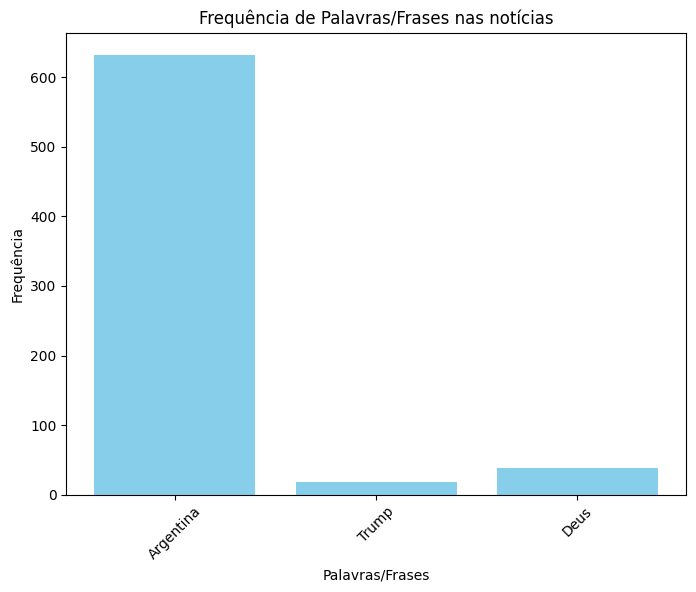

In [ ]:
import matplotlib.pyplot as plt

# Criar um gráfico de barras com as frequências
plt.figure(figsize=(8, 6))
plt.bar(frequencias_totais.keys(), frequencias_totais.values(), color='skyblue')
plt.xlabel('Palavras/Frases')
plt.ylabel('Frequência')
plt.title('Frequência de Palavras/Frases nas notícias')
plt.xticks(rotation=45)  # Rotacionar os rótulos para melhorar a legibilidade
plt.show()

Manipulação de Dados (Pandas)

### Seleção e Filtragem (`loc`, `iloc`, `at`, `iat`)
*   `at` / `iat`: Pega um valor único na coordenada exata (tipo PROCV). `at` usa os nomes (labels), `iat` usa posição numérica (i = integer).
    *   Substituição direta: `df.at['linha', 'coluna'] = 6`
*   `loc` / `iloc`: Filtra linhas/colunas. `loc` vai pelo nome do índice, `iloc` pela posição (0, 1, 2...).
*   Filtros com múltiplas condições exigem parênteses e operadores lógicos (`&` para E, `|` para OU).
    *   Exemplo: `df.loc[(df['col1'] > 2) & (df['col1'] < 5)]`
*   Negação: o til `~` inverte a condição. Ex: `~df['col1'].between(6, 10)` (pega o que NÃO está entre 6 e 10).
*   Filtro em lista: `df['col'].isin([1, 2, 3])`

### Lidando com Textos (Strings)
*   Sempre usar o acessor `.str` antes do método.
*   Tamanho: `df['col'].str.len() > 4`
*   Pesquisa de trecho: `df['col'].str.contains('texto')`. Aceita regex (ex: buscar duas palavras com `palavra1|palavra2`).

### Valores Nulos (NaN)
*   Busca: `.isnull()` ou `.isna()`. Inverso é `.notnull()`.
*   Apagar nulos: `.dropna()`.
    *   Padrão apaga qualquer linha (`axis=0`) que tenha 1 NaN. Pra apagar coluna, `axis=1`.
    *   `how='all'` apaga só se a linha/coluna inteira for NaN.
    *   `thresh=2` mantém a linha se ela tiver pelo menos 2 valores reais.
*   Apagar colunas/linhas específicas: `df.drop('nome', axis=1)`. O parâmetro `errors='ignore'` evita que o código quebre se a coluna não existir.

### Limpeza e Leitura de Arquivos
*   Erro de leitura (Codec utf-8) em arquivos do governo/BR: resolver passando `encoding='ISO-8859-1'` e `sep=';'` no `pd.read_csv()`.
*   Renomear colunas:
    *   Todas de uma vez: `df.columns = ['a', 'b', 'c']`
    *   Específicas: `df.rename(columns={'velho': 'novo'})`
    *   Limpando espaços em massa com List Comprehension: `df.columns = [col.replace(' ', '_') for col in df.columns]`

### Configurações de Exibição (Pandas e Colab)
*   Gráficos rápidos no Pandas: `df.plot(kind='bar')`. `subplots=True` quebra um gráfico por coluna.
*   Tirar os "..." do dataframe pra ver todas as colunas: `pd.set_option('display.max_columns', None)` (mesma lógica pra `max_rows`).
*   Casas decimais: `pd.set_option('display.precision', 2)`.
*   Voltar configurações ao padrão: `pd.reset_option('^display.', silent=True)`.
*   No Colab: Ajustar indentação pra 4 espaços (padrão Python), ativar números de linha nas configurações. Modo "Playground" ajuda a testar código sem salvar no notebook principal. Executar comandos de terminal exige `!` no começo da célula.

---

## Performance e Reshape

**1. Agrupamentos (`groupby`)**
*   Junta categorias tipo tabela dinâmica: `df.groupby('Estado').sum()`
*   Múltiplas colunas de grupo precisam ir numa lista: `df.groupby(['Estado', 'Partido']).sum()`
*   Resolver problema de Multi-Index: o agrupamento joga as colunas pro "índice". Evitar isso colocando `as_index=False` no groupby ou jogando um `.reset_index()` no final do código
*   Agregações específicas (`.agg`): passa um dicionário pra calcular coisas diferentes. Ex: `df.groupby('UF').agg({'Votos': 'sum', 'Idade': 'mean'})`.

**2. Otimização e Aplicação de Funções**
*   **`apply()`**: Mais versátil. Aplica uma função numa Series ou ao longo do eixo do Dataframe. Pode usar `lambda`.
    *   *Dica de performance:* No dataframe inteiro, passar `raw=True` faz o Pandas usar arrays do NumPy internamente. Fica bem mais rápido.
*   **`map()`**: Só existe para Series (1 coluna). Útilo para substituir valores cruzando com um dicionário.
*   **`transform()`**: Regra estrita -> o output tem que ter o mesmo tamanho do input. Opera coluna por coluna. Mais rápido que o apply pra operações vetorizadas numéricas, mas não consegue cruzar dados de colunas diferentes na mesma linha.
*   **`applymap()`**: Roda em Dataframes. Vai célula por célula (element-wise). Lento para cálculo matemático, mas ótimo para formatar strings em toda a tabela de uma vez.

**3. Tabela Dinâmica / Reshape (`pivot` e `pivot_table`)**
*   `pivot(index='A', columns='B', values='C')`: Reposiciona a tabela. A vira linha, B vira coluna.
*   `pivot_table()`: Versão segura do pivot. Se tiver dados duplicados na mesma interseção de linha x coluna, o pivot quebra. O `pivot_table` resolve isso tirando a média (`mean`) por padrão ou somando (`aggfunc='sum'`). E cria índice múltiplo automático se passar listas

# Manipulação de Dados com Pandas (Python)

## 1. Selecionando Valores Específicos (`at` e `iat`)
Alternativas eficientes para buscar/alterar valores únicos (semelhante ao PROCV/ÍNDICE CORRESP do Excel).
*   `df.at['nome_linha', 'nome_coluna']`: Busca baseada nas **labels** (nomes) dos índices e colunas.
*   `df.iat[0, 1]`: Busca baseada na **posição** (inteiros, começando em 0). O "i" indica *integer*.
*   **Substituição de valores:** Basta atribuir um novo valor direto na coordenada: `df.at['linha', 'coluna'] = 6`.

## 2. Filtragem de Linhas e Colunas (`loc` e `iloc`)
*   `df.loc[]`: Filtra através do **nome** do índice.
    *   Ex: `df.loc[['linha1', 'linha2']]` (retorna dataframe).
    *   Slicing: `df.loc['linha1':'linha3']` (inclui o final).
*   `df.iloc[]`: Filtra através da **posição numérica**.
    *   Ex: `df.iloc[[0, 2]]` (linhas 0 e 2).
    *   Slicing: `df.iloc[0:3]` (vai do 0 ao 2, não inclui o 3).
*   **Filtros com condições:** `df.loc[df['coluna1'] > 2]`.
    *   Múltiplas condições exigem parênteses e operadores *bitwise*: `&` (AND) ou `|` (OR).
    *   Ex: `df.loc[(df['col1'] > 2) & (df['col1'] < 5)]`.
*   **Alteração em massa:** `df.iloc[0] = 10` (transforma todos os valores da linha 0 em 10).

## 3. Filtros com Valores Numéricos
*   **Operadores Básicos:** Maior `>`, menor `<`, igual `==`.
*   **Função `between()`:** Filtra valores entre um intervalo. Ex: `df[df['col1'].between(6, 10)]`.
*   **Negação (`~`):** O til inverte a condição (o que não está no filtro). Ex: `df[~df['col1'].between(6, 10)]`.
*   **Por Funções Matemáticas:** Filtrar baseando-se na soma ou máximo da linha (`axis=1`).
    *   Ex: `df[df.sum(axis=1) == 12]`.
*   **Função `isin()`:** Verifica se o valor da célula pertence a uma lista. Ex: `df[df['col1'].isin([6, 12])]`.

## 4. Filtragem de Strings (Textos)
O Pandas possui o acessor `.str` para aplicar métodos de string em colunas inteiras.
*   **Filtro Exato:** `df[df['coluna'] == 'Olá']`.
*   **Comprimento (`len`):** Filtra pelo tamanho da palavra. Ex: `df[df['col'].str.len() > 4]`.
*   **Contém trecho (`contains`):** Busca por substrings. Ex: `df[df['col'].str.contains('Py')]`.
    *   Aceita múltiplas strings (Regex): `df[df['col'].str.contains('Bem vindos|Hoje')]`.
    *   sempr bom lembrar que caracteres especiais (como `+`) precisam ser escapados com barra invertida `\+`.

## 5. Tratamento de Valores Nulos (Missing / NaN) - Identificação
*   **Identificar nulos:** `df[df['coluna'].isnull()]` ou `isna()` (são idênticos).
*   **Não nulos:** Usar `notnull()` ou inverter com til: `~df['coluna'].isnull()`.
*   **Nulos em qualquer lugar da linha:** Usa-se o `.any()` analisando linhas (`axis=1`). Ex: `df[df.isnull().any(axis=1)]`.
*   **Contagem de Nulos:* Filtrar linhas que tenham exatamente "X" valores nulos. Ex: `df[df.isnull().sum(axis=1) == 2]`.

## 6. Visualização Gráfica Direta com Pandas
Não é estritamente necessário importar Matplotlib/Seaborn para gráficos rápidos.
*   **Básico:** `df.plot(kind='bar')` (tipos: bar, hist, kde, etc).
*   **Especificar eixos:** `df.plot(kind='bar', y='coluna_especifica')`.
*   **Subplots:** Cria um gráfico por coluna. `df.plot(subplots=True, layout=(3,3), figsize=(10,10))`.
*   **Alinhamento de Escala:** Para comparar gráficos corretamente, use `sharex=True` e `sharey=True`.
*   **Barras empilhadas:** `stacked=True`.
*   **Rotação do Eixo X:** `rot=0` (evita que o texto fique inclinado).

## 7. Formatação de Exibição (Display Options)
Útil quando o output tem muitas casas decimais ou notação científica.
*   **Casas Decimais:** `pd.set_option('display.precision', 2)`.
*   **Desativar Notação Científica:** Forçar formato float. Ex: `pd.set_option('display.float_format', '{:.3f}'.format)`.
*   **Resetar Padrão:** `pd.reset_option('^display.', silent=True)`.

## 8. Excluindo Valores Nulos (`dropna`)
*   **Básico:** `df.dropna()` (por padrão, apaga qualquer linha `axis=0` que tenha um NaN).
*   **Mudar Eixo:** `df.dropna(axis=1)` (apaga colunas com NaN).
*   **Parâmetro `how`:**
    *   `how='any'` (Padrão: apaga se tiver pelo menos 1 NaN).
    *   `how='all'` (Apaga apenas se TODOS os valores da linha/coluna forem NaN).
*   **Parâmetro `thresh` (Threshold):** Exige um mínimo de valores válidos. `thresh=2` (mantém a linha se tiver pelo menos 2 valores reais).
*   **Parâmetro `subset`:** Restringe a exclusão a uma coluna/linha específica. Ex: `subset=['coluna2']`.

## 9. Excluindo Linhas e Colunas (`drop`)
*   **Excluir Coluna:** `df.drop('nome_coluna', axis=1)`. (Se esquecer o `axis=1`, dará erro, pois o padrão é procurar nas linhas).
*   **Excluir Linha:** `df.drop(0, axis=0)`.
*   **Múltiplos valores:** Passar uma lista. Ex: `df.drop(['col1', 'col2'], axis=1)`.
*   **Ignorar Erros:** Se a coluna não existir, o código quebra. Para evitar: `errors='ignore'`.
*   **Aplicar no arquivo atual:** Para não precisar recriar a variável (`df = df.drop...`), use `inplace=True`.

## 10. Configurações Globais do DataFrame (Evitar reticências `...`)
*   **Mostrar todas as colunas:** `pd.set_option('display.max_columns', None)`.
*   **Mostrar todas as linhas:** `pd.set_option('display.max_rows', None)`.
*   **Ajustar largura do texto nas células:** `pd.set_option('display.max_colwidth', 8)`.
*   *(o tal do `reset_option` mencionado no item 7 faz voltr ao normal depois).*

## 11. Reordenando Colunas
*   **Manualmente:** Sobrescrever passando uma lista com a ordem desejada. `df = df[['B', 'C', 'A']]`.
*   **Alfabeticamente:** Extrair as colunas `df.columns`, converter para lista, aplicar o método nativo do Python `sorted()` e aplicar no df.
*   **Pelos valores numéricos de uma linha:** `df.sort_values(by=0, axis=1, ascending=False)`. (Organiza as colunas com base nos valores contidos na linha de índice 0).

***


